# Notebook 02 — Exploratory Analysis
**Dataset:** Brazilian E-Commerce (Olist) — `df_master.parquet`  
**Tujuan:** Analisis 5 area bisnis utama dan ekspor chart ke `output/figures/`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

OUT     = Path('../output')
FIGURES = OUT / 'figures'
FIGURES.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid', palette='Blues_d', font_scale=1.1)
BLUE  = '#2563EB'
RED   = '#DC2626'
GRAY  = '#6B7280'

df = pd.read_parquet(OUT / 'df_master.parquet')
# Konversi period agar bisa dioperasikan
df['order_month']   = df['order_month'].astype('period[M]')
df['order_quarter'] = df['order_quarter'].astype('period[Q]')
print(f'Loaded: {len(df):,} baris')
df.head(2)

Loaded: 110,197 baris


,order_id,customer_id,product_id,seller_id,order_purchase_timestamp,order_month,order_year,order_quarter,price,freight_value,...,payment_type,payment_value,review_score,customer_state,customer_city,category,delivery_days,is_late,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-02 10:56:33,2017-10,2017,2017Q4,29.99,8.72,...,voucher,38.71,4.0,SP,sao paulo,housewares,8.0,0,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-24 20:41:37,2018-07,2018,2018Q3,118.70,22.76,...,boleto,141.46,4.0,BA,barreiras,perfumery,13.0,0,2018-08-07 15:27:45,2018-08-13


---
## A. Revenue & Volume Trends

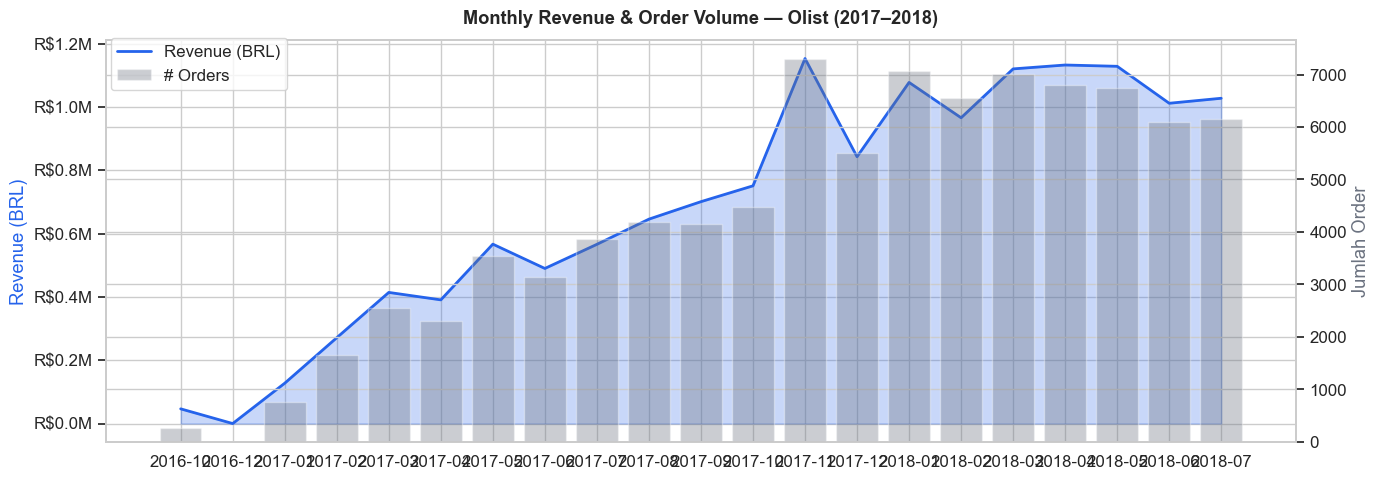

Saved: A_revenue_trend.png


In [2]:
monthly = (
    df.groupby('order_month')
    .agg(revenue=('revenue', 'sum'), orders=('order_id', 'nunique'))
    .reset_index()
)
monthly['month_str'] = monthly['order_month'].astype(str)

# Buang bulan pertama dan terakhir (data tidak lengkap)
monthly = monthly.iloc[1:-1].reset_index(drop=True)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.fill_between(monthly['month_str'], monthly['revenue'], alpha=0.25, color=BLUE)
ax1.plot(monthly['month_str'], monthly['revenue'], color=BLUE, linewidth=2, label='Revenue (BRL)')
ax2.bar(monthly['month_str'], monthly['orders'], alpha=0.35, color=GRAY, label='# Orders')

ax1.set_ylabel('Revenue (BRL)', color=BLUE)
ax2.set_ylabel('Jumlah Order', color=GRAY)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.title('Monthly Revenue & Order Volume — Olist (2017–2018)', fontweight='bold', pad=12)
fig.legend(loc='upper left', bbox_to_anchor=(0.08, 0.92))
plt.tight_layout()
plt.savefig(FIGURES / 'A_revenue_trend.png', dpi=150)
plt.show()
print('Saved: A_revenue_trend.png')

---
## B. Product Category Performance

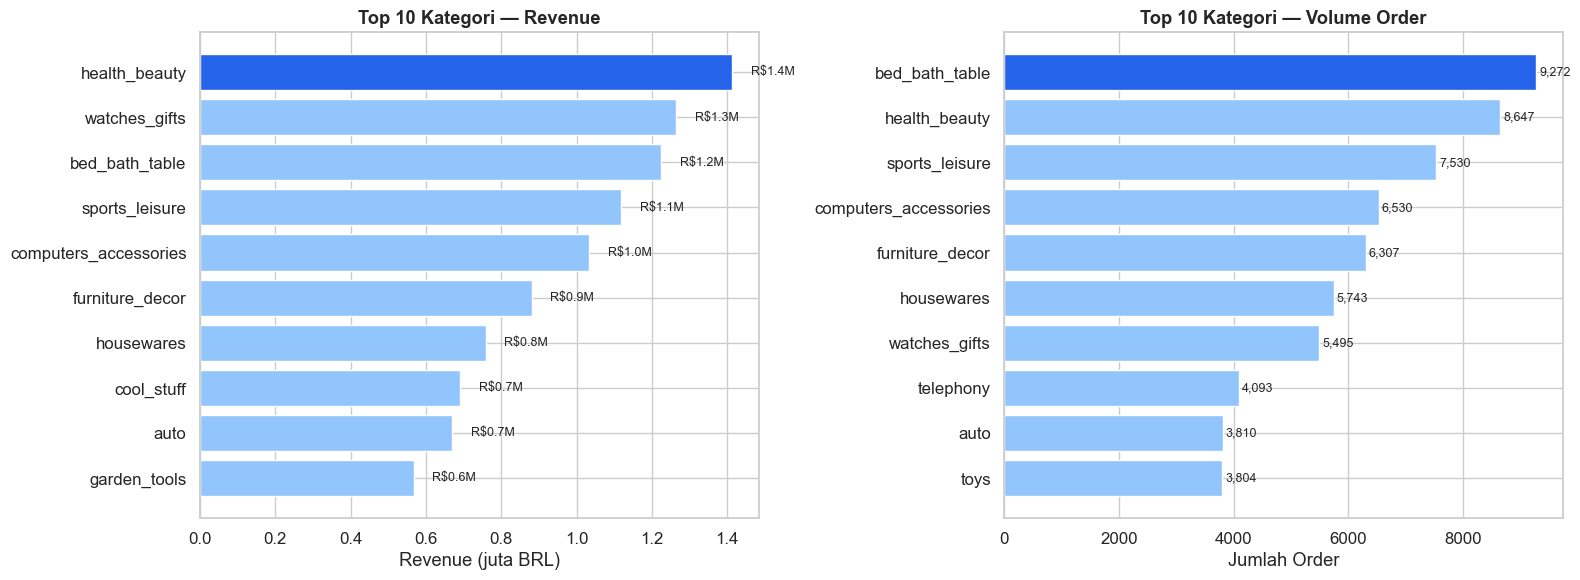

Saved: B_category_performance.png


In [3]:
cat_rev = (
    df.groupby('category')
    .agg(revenue=('revenue', 'sum'), orders=('order_id', 'nunique'))
    .sort_values('revenue', ascending=False)
    .head(10)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 by Revenue
colors_rev = [BLUE if i == 0 else '#93C5FD' for i in range(len(cat_rev))]
axes[0].barh(cat_rev['category'][::-1], cat_rev['revenue'][::-1] / 1e6, color=colors_rev[::-1])
axes[0].set_xlabel('Revenue (juta BRL)')
axes[0].set_title('Top 10 Kategori — Revenue', fontweight='bold')
for i, v in enumerate(cat_rev['revenue'][::-1] / 1e6):
    axes[0].text(v + 0.05, i, f'R${v:.1f}M', va='center', fontsize=9)

# Top 10 by Orders
cat_ord = (
    df.groupby('category')
    .agg(orders=('order_id', 'nunique'))
    .sort_values('orders', ascending=False)
    .head(10)
    .reset_index()
)
colors_ord = [BLUE if i == 0 else '#93C5FD' for i in range(len(cat_ord))]
axes[1].barh(cat_ord['category'][::-1], cat_ord['orders'][::-1], color=colors_ord[::-1])
axes[1].set_xlabel('Jumlah Order')
axes[1].set_title('Top 10 Kategori — Volume Order', fontweight='bold')
for i, v in enumerate(cat_ord['orders'][::-1]):
    axes[1].text(v + 50, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / 'B_category_performance.png', dpi=150)
plt.show()
print('Saved: B_category_performance.png')

---
## C. Geographic Analysis by State

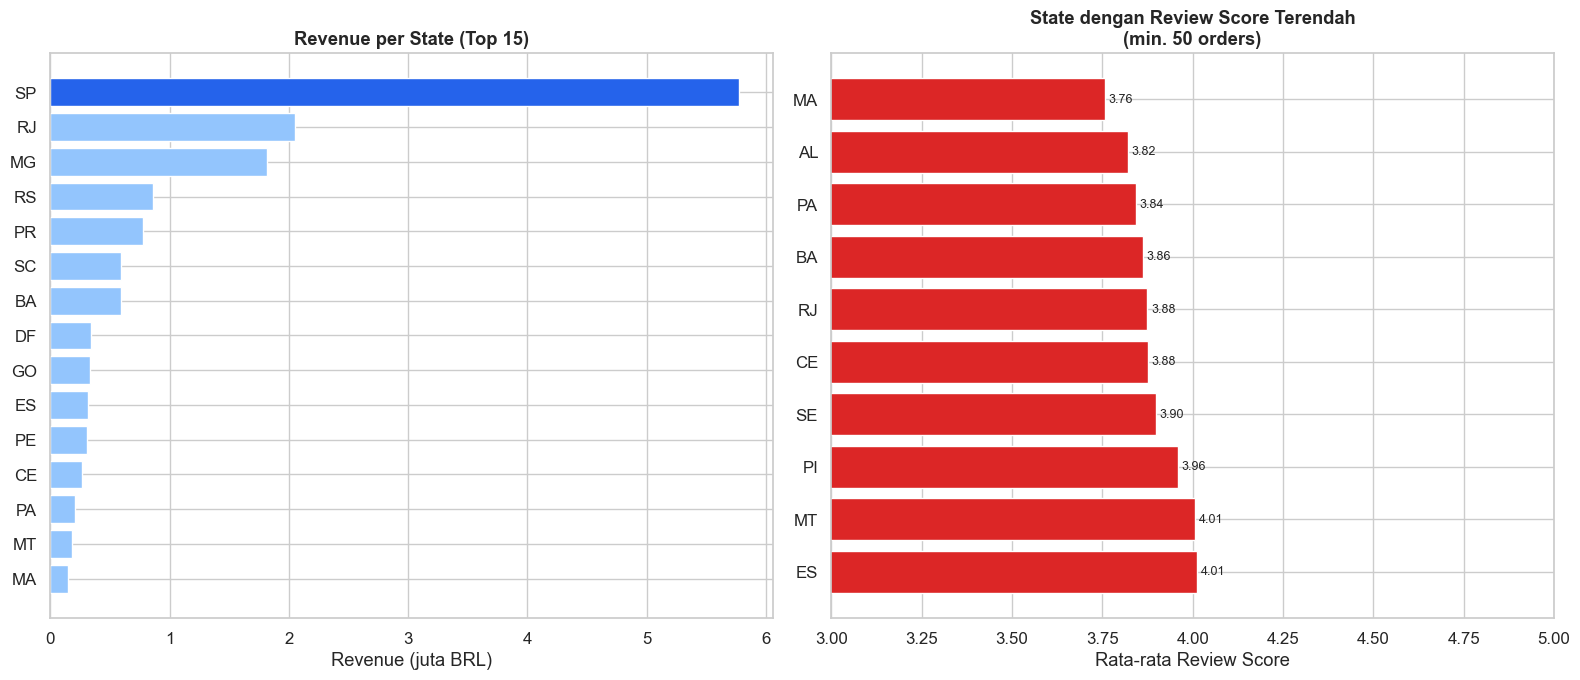

Saved: C_geographic_analysis.png


In [4]:
state_rev = (
    df.groupby('customer_state')
    .agg(revenue=('revenue', 'sum'), orders=('order_id', 'nunique'),
         avg_score=('review_score', 'mean'))
    .sort_values('revenue', ascending=False)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Revenue by state
top_states = state_rev.head(15)
palette_state = [BLUE if s == top_states['customer_state'].iloc[0] else '#93C5FD'
                 for s in top_states['customer_state']]
axes[0].barh(top_states['customer_state'][::-1], top_states['revenue'][::-1] / 1e6,
             color=palette_state[::-1])
axes[0].set_xlabel('Revenue (juta BRL)')
axes[0].set_title('Revenue per State (Top 15)', fontweight='bold')

# Review score by state (bottom 10 — opportunity)
worst_states = state_rev[state_rev['orders'] >= 50].nsmallest(10, 'avg_score')
axes[1].barh(worst_states['customer_state'][::-1], worst_states['avg_score'][::-1],
             color=RED)
axes[1].set_xlabel('Rata-rata Review Score')
axes[1].set_title('State dengan Review Score Terendah\n(min. 50 orders)', fontweight='bold')
axes[1].set_xlim(3, 5)
for i, v in enumerate(worst_states['avg_score'][::-1]):
    axes[1].text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / 'C_geographic_analysis.png', dpi=150)
plt.show()
print('Saved: C_geographic_analysis.png')

---
## D. Customer & Payment Analysis

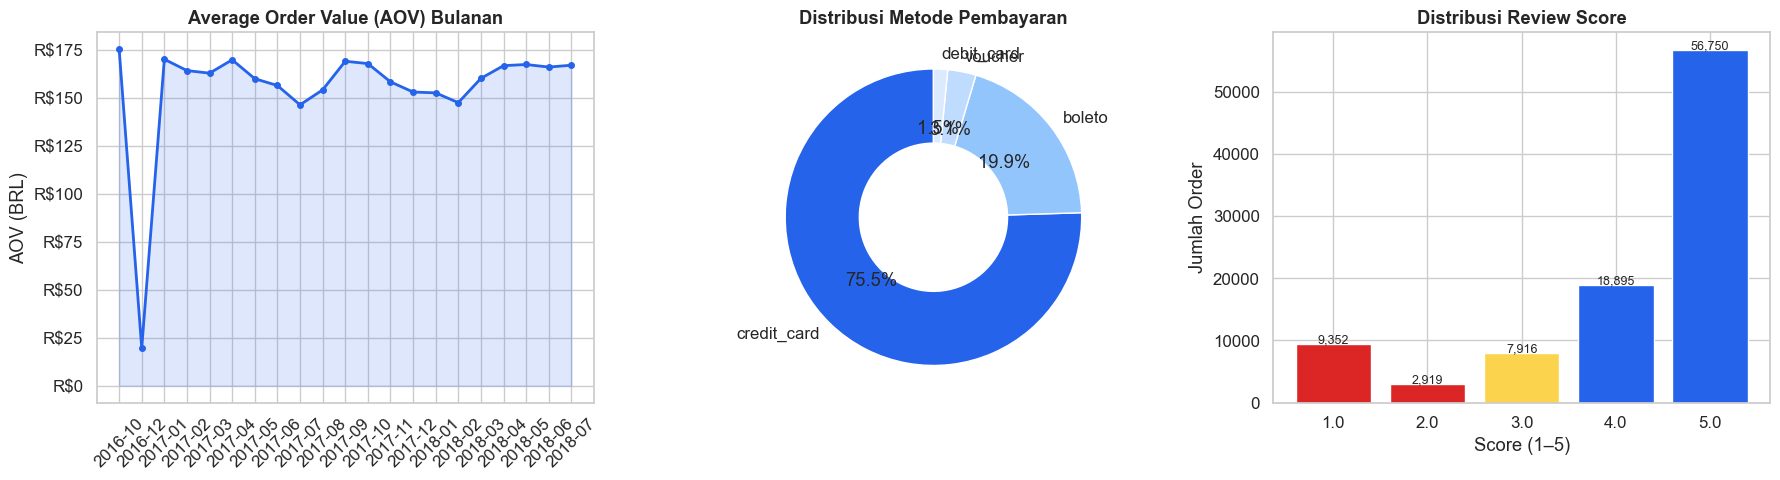

Saved: D_customer_payment.png


In [5]:
# AOV per bulan
aov = (
    df.groupby('order_month')
    .apply(lambda g: g.groupby('order_id')['revenue'].sum().mean())
    .reset_index()
)
aov.columns = ['order_month', 'aov']
aov['month_str'] = aov['order_month'].astype(str)
aov = aov.iloc[1:-1].reset_index(drop=True)

# Payment type distribution
pay_dist = df.drop_duplicates('order_id')['payment_type'].value_counts()

# Review score distribution
score_dist = df.drop_duplicates('order_id')['review_score'].value_counts().sort_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# AOV trend
axes[0].plot(aov['month_str'], aov['aov'], color=BLUE, linewidth=2, marker='o', markersize=4)
axes[0].fill_between(aov['month_str'], aov['aov'], alpha=0.15, color=BLUE)
axes[0].set_title('Average Order Value (AOV) Bulanan', fontweight='bold')
axes[0].set_ylabel('AOV (BRL)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:.0f}'))
axes[0].tick_params(axis='x', rotation=45)

# Payment donut
wedge_colors = [BLUE, '#93C5FD', '#BFDBFE', '#DBEAFE']
axes[1].pie(pay_dist.values, labels=pay_dist.index, autopct='%1.1f%%',
            colors=wedge_colors, wedgeprops={'width': 0.5}, startangle=90)
axes[1].set_title('Distribusi Metode Pembayaran', fontweight='bold')

# Review score bar
bar_colors = [RED if s <= 2 else ('#FCD34D' if s == 3 else BLUE) for s in score_dist.index]
axes[2].bar(score_dist.index.astype(str), score_dist.values, color=bar_colors)
axes[2].set_title('Distribusi Review Score', fontweight='bold')
axes[2].set_xlabel('Score (1–5)')
axes[2].set_ylabel('Jumlah Order')
for i, v in enumerate(score_dist.values):
    axes[2].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / 'D_customer_payment.png', dpi=150)
plt.show()
print('Saved: D_customer_payment.png')

---
## E. Delivery Performance

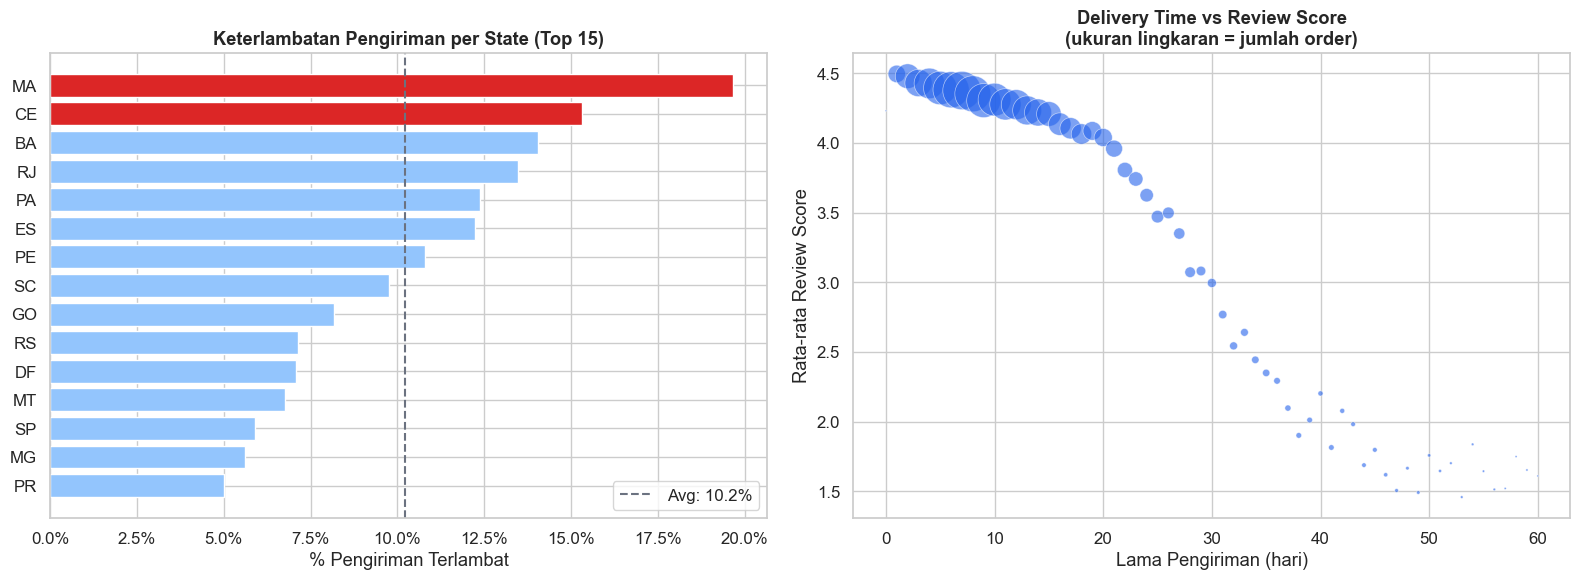

Saved: E_delivery_performance.png


In [6]:
# % late per state (top 15 states by order volume)
top15_states = (
    df.drop_duplicates('order_id')
    .groupby('customer_state')['order_id'].count()
    .nlargest(15).index
)
delivery_state = (
    df[df['customer_state'].isin(top15_states)]
    .drop_duplicates('order_id')
    .groupby('customer_state')
    .agg(late_pct=('is_late', 'mean'), avg_days=('delivery_days', 'median'))
    .sort_values('late_pct', ascending=False)
    .reset_index()
)

# Scatter: delivery days vs review score
scatter_data = (
    df.drop_duplicates('order_id')
    .dropna(subset=['delivery_days', 'review_score'])
    .groupby('delivery_days')
    .agg(avg_score=('review_score', 'mean'), count=('order_id', 'count'))
    .reset_index()
    .query('delivery_days <= 60 and count >= 10')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# % late per state
bar_colors_late = [RED if v > 0.15 else '#93C5FD' for v in delivery_state['late_pct']]
axes[0].barh(delivery_state['customer_state'][::-1],
             delivery_state['late_pct'][::-1] * 100,
             color=bar_colors_late[::-1])
axes[0].axvline(delivery_state['late_pct'].mean() * 100, color=GRAY,
                linestyle='--', linewidth=1.5, label=f'Avg: {delivery_state["late_pct"].mean()*100:.1f}%')
axes[0].set_xlabel('% Pengiriman Terlambat')
axes[0].set_title('Keterlambatan Pengiriman per State (Top 15)', fontweight='bold')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter())

# Scatter delivery days vs review score
sc = axes[1].scatter(scatter_data['delivery_days'], scatter_data['avg_score'],
                     s=scatter_data['count'] / 10, alpha=0.6, color=BLUE,
                     edgecolors='white', linewidth=0.5)
axes[1].set_xlabel('Lama Pengiriman (hari)')
axes[1].set_ylabel('Rata-rata Review Score')
axes[1].set_title('Delivery Time vs Review Score\n(ukuran lingkaran = jumlah order)', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES / 'E_delivery_performance.png', dpi=150)
plt.show()
print('Saved: E_delivery_performance.png')

---
## Ringkasan KPI

In [7]:
total_revenue = df['revenue'].sum()
total_orders  = df['order_id'].nunique()
aov_overall   = df.groupby('order_id')['revenue'].sum().mean()
avg_score     = df.drop_duplicates('order_id')['review_score'].mean()
late_pct      = df.drop_duplicates('order_id')['is_late'].mean() * 100

print('=' * 45)
print(f'  Total Revenue  : R$ {total_revenue:>12,.0f}')
print(f'  Total Orders   : {total_orders:>14,}')
print(f'  AOV            : R$ {aov_overall:>12,.0f}')
print(f'  Avg Review     : {avg_score:>14.2f} / 5.0')
print(f'  Late Delivery  : {late_pct:>13.1f} %')
print('=' * 45)

  Total Revenue  : R$   15,419,774
  Total Orders   :         96,478
  AOV            : R$          160
  Avg Review     :           4.16 / 5.0
  Late Delivery  :           8.1 %
